**Machine learning internship task 2**

**1.Upload costumer churn dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data_telco_customer_churn.csv to data_telco_customer_churn.csv


**2.Import All Libraries**

In [4]:
# Importing necessary libraries for data analysis and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

**3.Data Preprocessing**

**Handling Missing Values:** Use SimpleImputer to fill missing values.

**Outlier Detection:** Visualize using boxplots, and remove or replace outliers if necessary.
**Categorical Encoding:** Convert categorical variables using Label Encoding or OneHot Encoding.

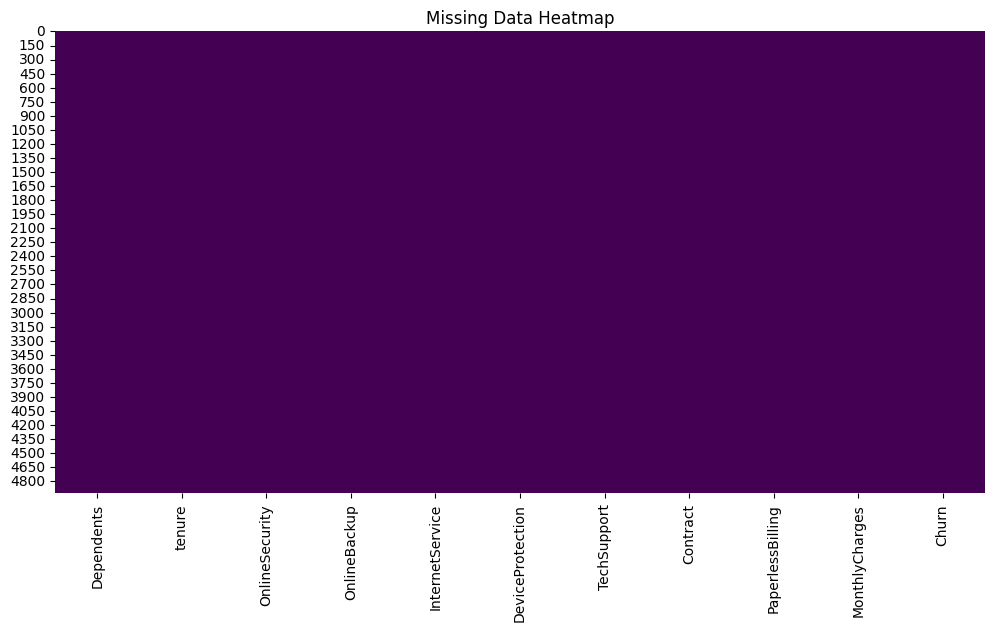

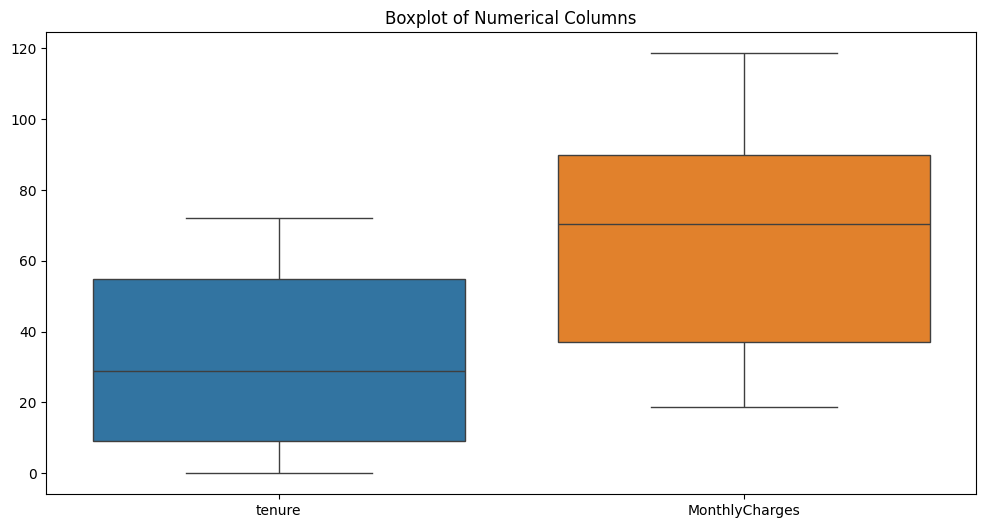

In [5]:
# Load the dataset
df = pd.read_csv('data_telco_customer_churn.csv')

# Handle missing values using SimpleImputer (we'll use the 'most_frequent' strategy for categorical columns)
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Handle categorical variables using LabelEncoder (for categorical columns, including 'Churn')
categorical_columns = ['Dependents', 'OnlineSecurity', 'OnlineBackup', 'InternetService', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'Churn']
label_encoder = LabelEncoder()

# Apply label encoding to each categorical column
for col in categorical_columns:
    df_imputed[col] = label_encoder.fit_transform(df_imputed[col])

# Visualize missing data and outliers
plt.figure(figsize=(12, 6))
sns.heatmap(df_imputed.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# Boxplot to identify outliers (for numerical columns)
numerical_columns = ['tenure', 'MonthlyCharges']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_imputed[numerical_columns])
plt.title("Boxplot of Numerical Columns")
plt.show()

**4.Exploratory Data Analysis (EDA)**

Perform EDA to understand the relationships between features and churn:

        Dependents  OnlineSecurity  OnlineBackup  InternetService  \
count  4930.000000     4930.000000   4930.000000      4930.000000   
mean      0.301014        0.794726      0.905477         0.867343   
std       0.458745        0.862917      0.881950         0.736168   
min       0.000000        0.000000      0.000000         0.000000   
25%       0.000000        0.000000      0.000000         0.000000   
50%       0.000000        1.000000      1.000000         1.000000   
75%       1.000000        2.000000      2.000000         1.000000   
max       1.000000        2.000000      2.000000         2.000000   

       DeviceProtection  TechSupport     Contract  PaperlessBilling  \
count       4930.000000  4930.000000  4930.000000       4930.000000   
mean           0.899797     0.785801     0.682759          0.599797   
std            0.881323     0.860745     0.828317          0.489989   
min            0.000000     0.000000     0.000000          0.000000   
25%            0.000000

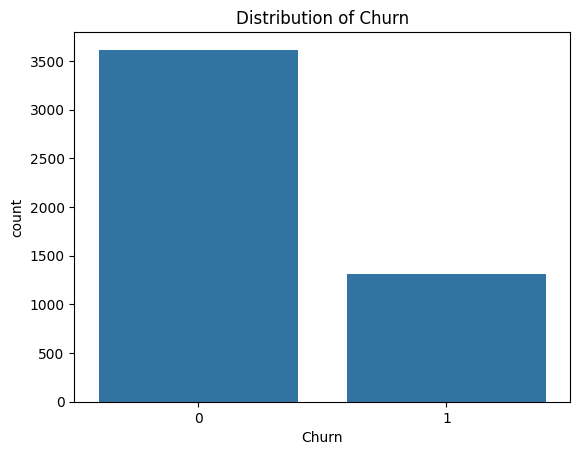

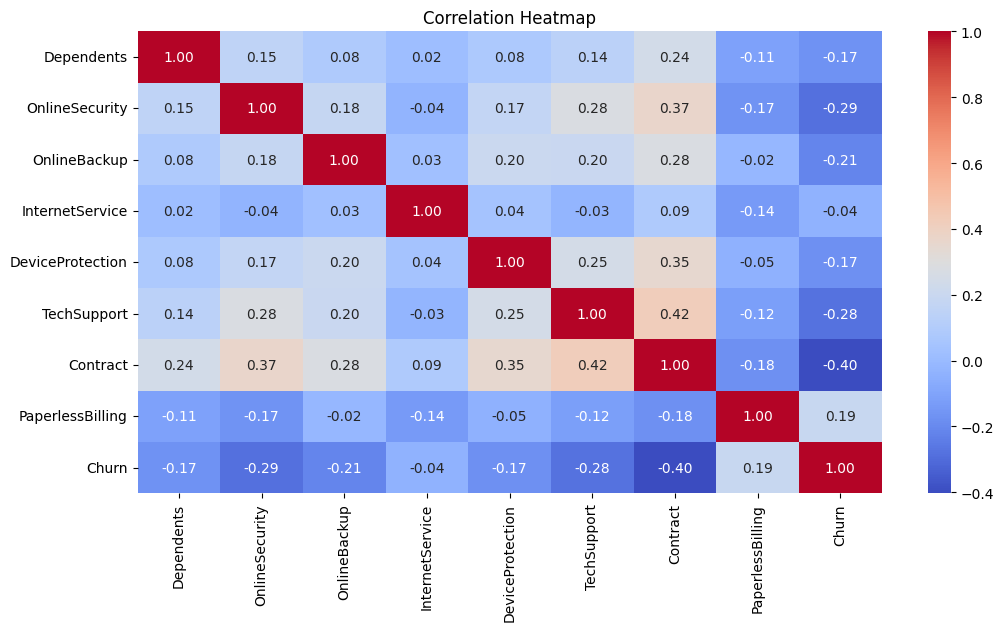

In [6]:
# Display summary statistics
print(df_imputed.describe())

# Visualize the distribution of the target variable (Churn)
sns.countplot(data=df_imputed, x='Churn')
plt.title("Distribution of Churn")
plt.show()

# Correlation heatmap (only for numeric columns)
plt.figure(figsize=(12, 6))
sns.heatmap(df_imputed.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

**5.Train-Test Split**

Split the data into training and testing sets:

In [7]:


# Define feature columns (X) and target variable (y)
X = df_imputed.drop('Churn', axis=1)  # Assuming 'Churn' is the target variable
y = df_imputed['Churn']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**6.Feature Scaling**

Apply scaling for better model performance:

In [8]:
# Apply scaling for better model performance using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**7.Model Training**

Train multiple machine learning models like Logistic Regression, Random Forest, and Gradient Boosting:

In [9]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

**8.Model Evaluation**

Evaluate the models using metrics like accuracy, precision, recall, F1-score, and ROC-AUC:

In [10]:
# Predictions
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)
gb_pred = gb_model.predict(X_test_scaled)

# Ensure y_test and predictions are numerical (0 or 1)
# Assuming 'Yes' was encoded as 1 and 'No' as 0 by LabelEncoder.
# If y_test is still object dtype, convert it.
if y_test.dtype == 'object':
    y_test_numeric = y_test.map({'No': 0, 'Yes': 1}).astype(int)
else:
    y_test_numeric = y_test

# Convert predictions if they are still object dtype
if lr_pred.dtype == 'object':
    lr_pred_numeric = np.array([1 if p == 'Yes' else 0 for p in lr_pred]).astype(int)
else:
    lr_pred_numeric = lr_pred

if rf_pred.dtype == 'object':
    rf_pred_numeric = np.array([1 if p == 'Yes' else 0 for p in rf_pred]).astype(int)
else:
    rf_pred_numeric = rf_pred

if gb_pred.dtype == 'object':
    gb_pred_numeric = np.array([1 if p == 'Yes' else 0 for p in gb_pred]).astype(int)
else:
    gb_pred_numeric = gb_pred


# Evaluation Metrics
def evaluate_model(model_name, y_true, y_pred_values):
    print(f"{model_name} - Accuracy:", accuracy_score(y_true, y_pred_values))
    print(f"{model_name} - Precision:", precision_score(y_true, y_pred_values, pos_label=1))
    print(f"{model_name} - Recall:", recall_score(y_true, y_pred_values, pos_label=1))
    print(f"{model_name} - F1 Score:", f1_score(y_true, y_pred_values, pos_label=1))
    # ROC AUC does not take pos_label if y_true and y_pred are 0/1.
    print(f"{model_name} - ROC AUC:", roc_auc_score(y_true, y_pred_values))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred_values))

evaluate_model('Logistic Regression', y_test_numeric, lr_pred_numeric)
evaluate_model('Random Forest', y_test_numeric, rf_pred_numeric)
evaluate_model('Gradient Boosting', y_test_numeric, gb_pred_numeric)


Logistic Regression - Accuracy: 0.7924273157538878
Logistic Regression - Precision: 0.6773162939297125
Logistic Regression - Recall: 0.507177033492823
Logistic Regression - F1 Score: 0.5800273597811217
Logistic Regression - ROC AUC: 0.7059919097718592
Confusion Matrix:
[[960 101]
 [206 212]]
Random Forest - Accuracy: 0.7647058823529411
Random Forest - Precision: 0.6107594936708861
Random Forest - Recall: 0.46172248803827753
Random Forest - F1 Score: 0.5258855585831063
Random Forest - ROC AUC: 0.6728970592877532
Confusion Matrix:
[[938 123]
 [225 193]]
Gradient Boosting - Accuracy: 0.7910750507099391
Gradient Boosting - Precision: 0.6719242902208202
Gradient Boosting - Recall: 0.5095693779904307
Gradient Boosting - F1 Score: 0.5795918367346938
Gradient Boosting - ROC AUC: 0.7057743214174585
Confusion Matrix:
[[957 104]
 [205 213]]


In [11]:
df.to_csv('CostumerChurnModel.csv', index=False)

In [12]:
from google.colab import files

files.download('CostumerChurnModel.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>